In [1]:
# ── Imports ────────────────────────────────────────────
import warnings
from pathlib import Path
from datetime import timedelta

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# ── Load clean data ────────────────────────────────────
df = pd.read_parquet("../data/retail_clean.parquet")
df["invoicedate"] = pd.to_datetime(df["invoicedate"])

print(f"Shape: {df.shape}")
print(f"Customers: {df['customer_id'].nunique():,}")
df.head()

Shape: (779425, 15)
Customers: 5,878


,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,revenue,year_month,year,month,day_of_week,hour,is_uk
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12,2009,12,1,7,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009,12,1,7,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009,12,1,7,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12,2009,12,1,7,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12,2009,12,1,7,1


In [2]:
# ── RFM Calculation ────────────────────────────────────
# Reference date = 1 day after last transaction in dataset
reference_date = df["invoicedate"].max() + timedelta(days=1)
print(f"Reference date: {reference_date}")

rfm = (
    df.groupby("customer_id")
    .agg(
        recency    = ("invoicedate", lambda x: (reference_date - x.max()).days),
        frequency  = ("invoice",     "nunique"),
        monetary   = ("revenue",     "sum"),
    )
    .reset_index()
)

# Add extra features for richer segmentation
customer_extras = (
    df.groupby("customer_id")
    .agg(
        avg_order_value  = ("revenue",     "mean"),
        unique_products  = ("stockcode",   "nunique"),
        avg_quantity     = ("quantity",     "mean"),
        tenure_days      = ("invoicedate", lambda x: (x.max() - x.min()).days),
        total_orders     = ("invoice",     "nunique"),
        is_uk            = ("is_uk",       "first"),
    )
    .reset_index()
)

rfm = rfm.merge(customer_extras, on="customer_id")

print(f"\nRFM shape: {rfm.shape}")
print(f"\n── RFM Summary Stats ──────────────────────────")
rfm[["recency", "frequency", "monetary"]].describe().round(2)

Reference date: 2011-12-10 12:50:00

RFM shape: (5878, 10)

── RFM Summary Stats ──────────────────────────


,recency,frequency,monetary
count,5878.00,5878.00,5878.00
mean,201.33,6.29,2915.25
std,209.34,13.01,14235.33
min,1.00,1.00,2.95
25%,26.00,1.00,342.28
50%,96.00,3.00,867.74
75%,380.00,7.00,2248.30
max,739.00,398.00,580987.04


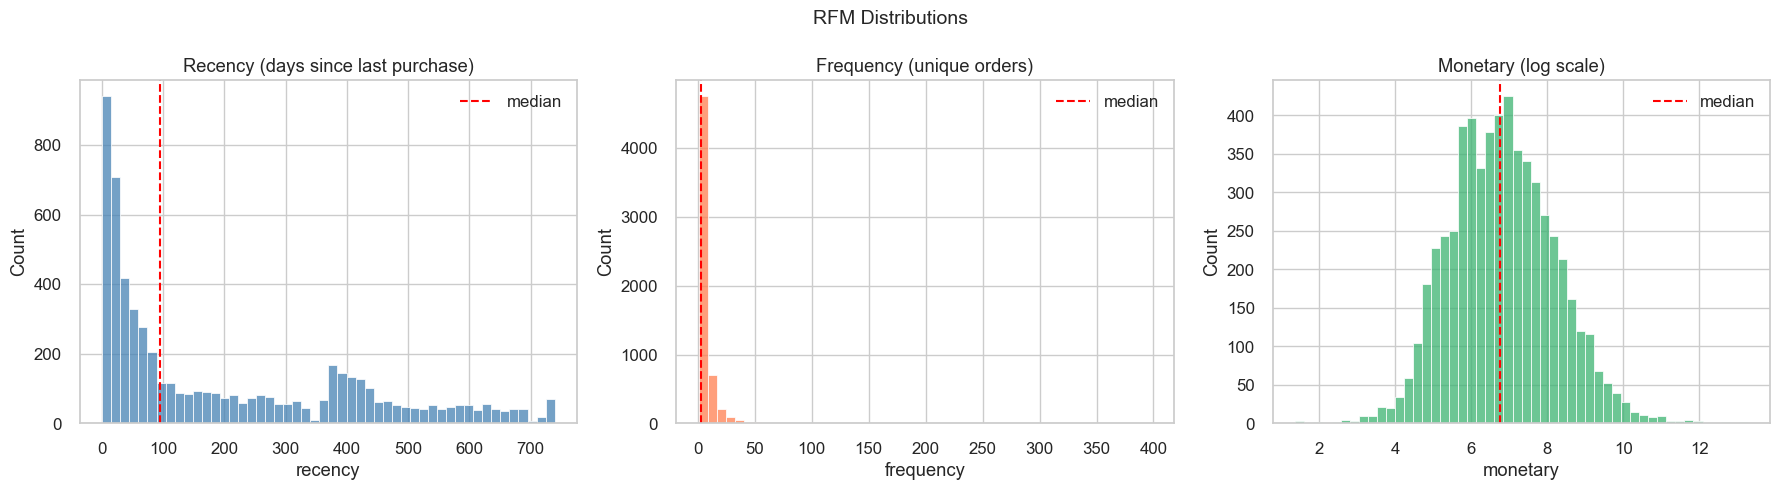

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("RFM Distributions", fontsize=14)

# Recency
sns.histplot(rfm["recency"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Recency (days since last purchase)")
axes[0].axvline(rfm["recency"].median(), color="red", ls="--", label="median")
axes[0].legend()

# Frequency
sns.histplot(rfm["frequency"], bins=50, ax=axes[1], color="coral")
axes[1].set_title("Frequency (unique orders)")
axes[1].axvline(rfm["frequency"].median(), color="red", ls="--", label="median")
axes[1].legend()

# Monetary — use log scale because of skew
sns.histplot(np.log1p(rfm["monetary"]), bins=50, ax=axes[2], color="mediumseagreen")
axes[2].set_title("Monetary (log scale)")
axes[2].axvline(np.log1p(rfm["monetary"].median()), color="red", ls="--", label="median")
axes[2].legend()

plt.tight_layout()
plt.savefig("../reports/03_rfm_distributions.png", dpi=150)
plt.show()

In [4]:
# ── Prepare features for clustering ────────────────────
# Log-transform monetary and frequency to reduce skew
rfm["monetary_log"]  = np.log1p(rfm["monetary"])
rfm["frequency_log"] = np.log1p(rfm["frequency"])

# Select features for clustering
cluster_features = ["recency", "frequency_log", "monetary_log"]
X = rfm[cluster_features].copy()

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Clustering features: {cluster_features}")
print(f"Scaled shape: {X_scaled.shape}")
print(f"Mean after scaling: {X_scaled.mean(axis=0).round(4)}")
print(f"Std after scaling : {X_scaled.std(axis=0).round(4)}")

Clustering features: ['recency', 'frequency_log', 'monetary_log']
Scaled shape: (5878, 3)
Mean after scaling: [-0.  0. -0.]
Std after scaling : [1. 1. 1.]


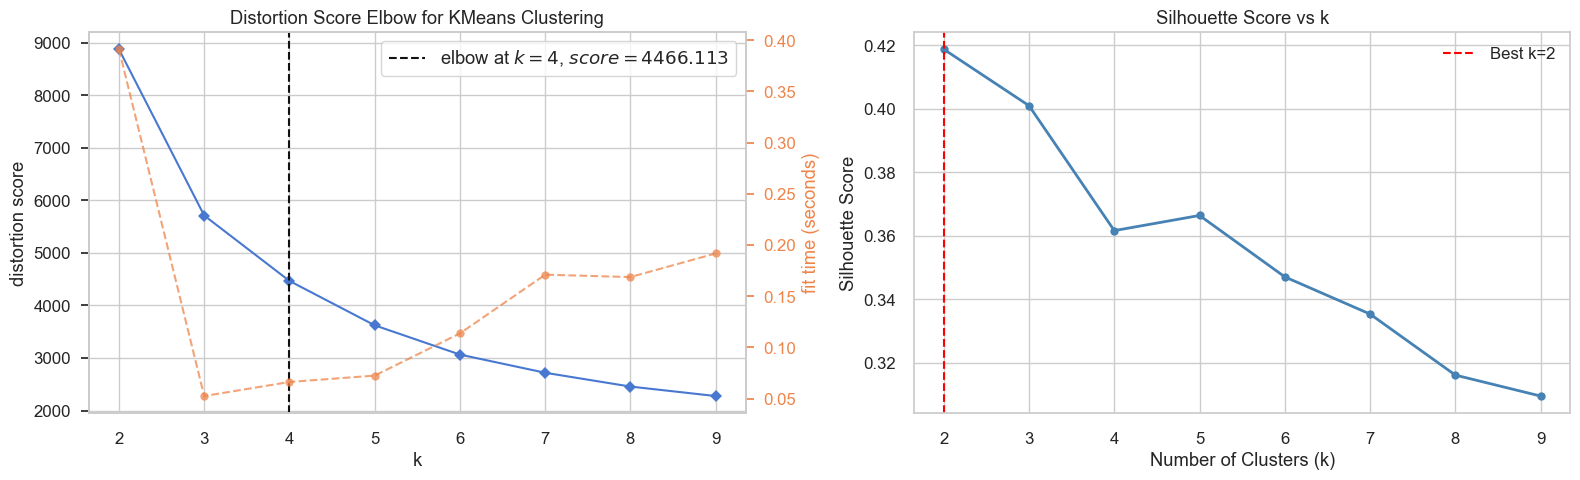


Best k by silhouette: 2


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Elbow plot
model = KMeans(random_state=42, n_init=10)
viz_elbow = KElbowVisualizer(model, k=(2, 10), ax=axes[0])
viz_elbow.fit(X_scaled)
viz_elbow.finalize()

# Silhouette scores for each k
sil_scores = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score  = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

axes[1].plot(K_range, sil_scores, marker="o", linewidth=2, color="steelblue")
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].axvline(
    K_range[np.argmax(sil_scores)],
    color="red", ls="--",
    label=f"Best k={K_range[np.argmax(sil_scores)]}"
)
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/04_elbow_silhouette.png", dpi=150)
plt.show()

best_k = K_range[np.argmax(sil_scores)]
print(f"\nBest k by silhouette: {best_k}")

PCA explained variance: [0.748 0.203]
Total variance captured: 95.1%


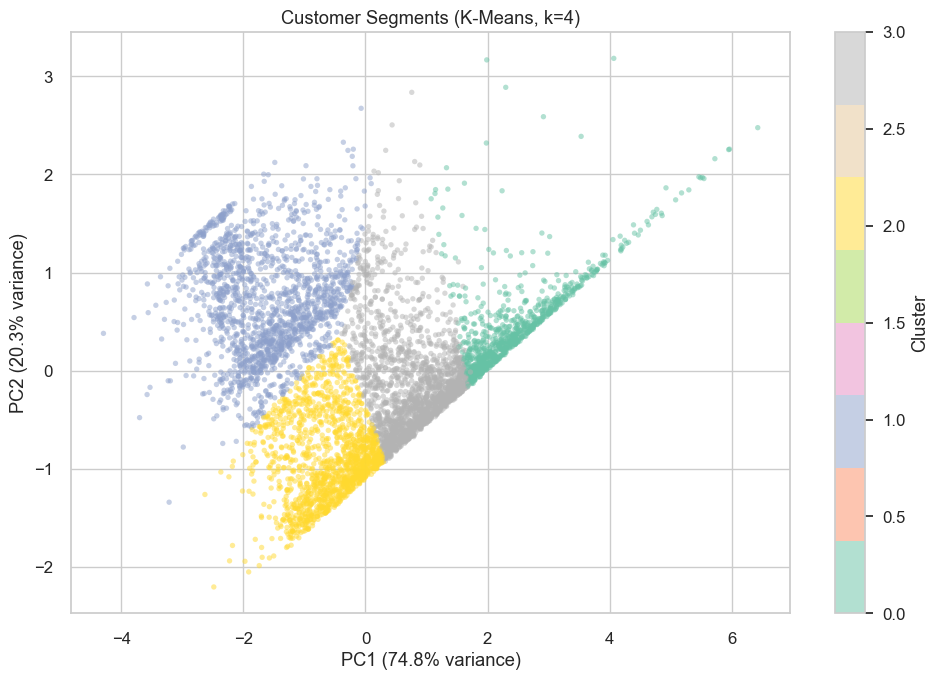

In [10]:
# ── Fit final model ────────────────────────────────────
# Use the best_k from silhouette, or override to 4 if you
# prefer the business interpretation (adjust as needed)
#CHOSEN_K = best_k
CHOSEN_K = 4  # Business decision: 4 segments gives actionable groups

km_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
rfm["cluster"] = km_final.fit_predict(X_scaled)

# ── PCA for 2D visualization ──────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
rfm["pca_1"] = X_pca[:, 0]
rfm["pca_2"] = X_pca[:, 1]

print(f"PCA explained variance: {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance captured: {pca.explained_variance_ratio_.sum():.1%}")

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    rfm["pca_1"], rfm["pca_2"],
    c=rfm["cluster"], cmap="Set2",
    alpha=0.5, s=15, edgecolors="none"
)
ax.set_title(f"Customer Segments (K-Means, k={CHOSEN_K})")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.savefig("../reports/05_pca_clusters.png", dpi=150)
plt.show()

── Segment Profiles ────────────────────────────
         count  avg_recency  avg_frequency  avg_monetary  avg_tenure  avg_products  pct_of_total
cluster                                                                                         
0          875         38.4           23.4       13389.0       612.5         234.3          14.9
1         1644        492.2            1.7         509.3        55.3          29.9          28.0
2         1495        103.1            1.8         460.8       140.3          32.0          25.4
3         1864        100.1            5.8        2089.2       412.2          96.5          31.7


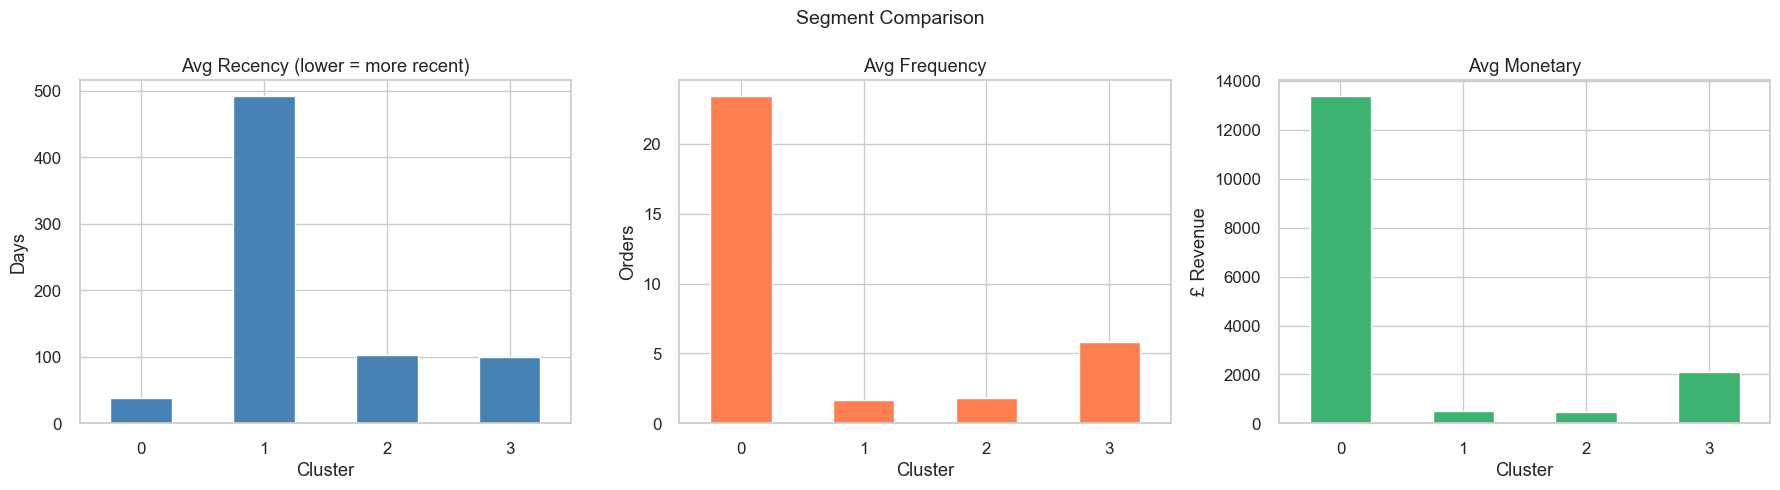

In [11]:
# ── Segment profiles ───────────────────────────────────
profile = (
    rfm.groupby("cluster")
    .agg(
        count          = ("customer_id",     "count"),
        avg_recency    = ("recency",         "mean"),
        avg_frequency  = ("frequency",       "mean"),
        avg_monetary   = ("monetary",        "mean"),
        avg_tenure     = ("tenure_days",     "mean"),
        avg_products   = ("unique_products", "mean"),
    )
    .round(1)
)

# Calculate percentage of total customers
profile["pct_of_total"] = (profile["count"] / profile["count"].sum() * 100).round(1)

print("── Segment Profiles ────────────────────────────")
print(profile.to_string())

# ── Visualize profiles ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Segment Comparison", fontsize=14)

profile["avg_recency"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Avg Recency (lower = more recent)")
axes[0].set_ylabel("Days")

profile["avg_frequency"].plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Avg Frequency")
axes[1].set_ylabel("Orders")

profile["avg_monetary"].plot(kind="bar", ax=axes[2], color="mediumseagreen")
axes[2].set_title("Avg Monetary")
axes[2].set_ylabel("£ Revenue")

for ax in axes:
    ax.set_xlabel("Cluster")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("../reports/06_segment_profiles.png", dpi=150)
plt.show()

In [17]:
# ── Name segments based on profiles ────────────────────
# Look at the profile table above and assign names.
# Adjust this mapping based on YOUR cluster numbers!
# Typical pattern:
#   High frequency + high monetary + low recency → VIP
#   Low frequency + high recency                 → At Risk / Churned
#   Medium everything                            → Core Regulars
#   1 order only                                 → New / One-timers

# IMPORTANT: Review your profile table and update this dict
# Sort clusters by avg_monetary to make naming deterministic
cluster_order = (
    profile["avg_monetary"]
    .sort_values(ascending=False)
    .index.tolist()
)

# Name by revenue rank — highest spenders first
name_map = {
    cluster_order[0]: "VIP Champions",
    cluster_order[1]: "Loyal Regulars",
    cluster_order[2]: "Churned / Lost",       # 492 days recency = gone
    cluster_order[3]: "New / One-timers",      # low frequency, recent-ish
}

rfm["segment_name"] = rfm["cluster"].map(name_map)

print("\n── Named Segments ──────────────────────────────")
print(rfm["segment_name"].value_counts())

# ── Quick DBSCAN comparison ───────────────────────────
print("\n── DBSCAN Comparison ───────────────────────────")
dbscan = DBSCAN(eps=0.8, min_samples=10)
rfm["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

n_clusters  = len(set(rfm["dbscan_cluster"])) - (1 if -1 in rfm["dbscan_cluster"].values else 0)
n_noise     = (rfm["dbscan_cluster"] == -1).sum()

print(f"DBSCAN clusters found : {n_clusters}")
print(f"Noise points          : {n_noise:,} ({100*n_noise/len(rfm):.1f}%)")
print(f"\nVerdict: K-Means is better here because our data doesn't")
print(f"have density-based clusters — RFM features form spherical")
print(f"groups which K-Means handles naturally. DBSCAN treats many")
print(f"customers as noise, which isn't useful for segmentation.")


── Named Segments ──────────────────────────────
segment_name
Loyal Regulars      1864
Churned / Lost      1644
New / One-timers    1495
VIP Champions        875
Name: count, dtype: int64

── DBSCAN Comparison ───────────────────────────
DBSCAN clusters found : 1
Noise points          : 17 (0.3%)

Verdict: K-Means is better here because our data doesn't
have density-based clusters — RFM features form spherical
groups which K-Means handles naturally. DBSCAN treats many
customers as noise, which isn't useful for segmentation.


In [18]:
# ── Save segment data ──────────────────────────────────
output_cols = [
    "customer_id", "recency", "frequency", "monetary",
    "avg_order_value", "unique_products", "avg_quantity",
    "tenure_days", "total_orders", "is_uk",
    "cluster", "segment_name"
]

rfm[output_cols].to_parquet("../data/segments.parquet", index=False)
print(f"Saved → data/segments.parquet ({len(rfm):,} customers)")

# Quick final summary
print("\n── Final Segment Summary ───────────────────────")
summary = (
    rfm.groupby("segment_name")
    .agg(
        customers     = ("customer_id", "count"),
        avg_recency   = ("recency",     "mean"),
        avg_frequency = ("frequency",   "mean"),
        total_revenue = ("monetary",    "sum"),
    )
    .round(1)
)
summary["revenue_pct"] = (summary["total_revenue"] / summary["total_revenue"].sum() * 100).round(1)
print(summary.to_string())

Saved → data/segments.parquet (5,878 customers)

── Final Segment Summary ───────────────────────
                  customers  avg_recency  avg_frequency  total_revenue  revenue_pct
segment_name                                                                       
Churned / Lost         1644        492.2            1.7       837218.8          4.9
Loyal Regulars         1864        100.1            5.8      3894275.5         22.7
New / One-timers       1495        103.1            1.8       688960.6          4.0
VIP Champions           875         38.4           23.4     11715399.6         68.4
